# BB84 QKD Performance Analysis: Cat Qubits vs Standard Qubits

**Course:** Quantum Simulation & Computing Lab  
**Project:** Photonic Quantum Error Correction — simulating cat qubit biased noise using Qiskit

We simulate the BB84 protocol under two noise models:
- **Standard qubit**: symmetric depolarizing noise
- **Cat qubit proxy**: biased Pauli channel with tunable bias ratio κ

The key idea is that cat qubits suppress bit-flip (X) errors exponentially while phase-flip (Z) errors dominate. We use κ = p_Z / p_X to parameterize the bias and sweep it to show the communication advantage.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
from qiskit.compiler import transpile

# dark theme for plots
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'font.family': 'monospace',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'figure.dpi': 120,
})

BLUE   = '#58a6ff'
TEAL   = '#39d353'
ORANGE = '#f78166'
YELLOW = '#e3b341'

print('imports done')

imports done


## Noise Models

**Standard**: depolarizing noise, equal probability p/3 for X, Y, Z errors  
**Cat qubit proxy**: biased Pauli channel where p_Z >> p_X

Given bias ratio κ and total noise p_total:
- p_X = p_Y = p_total / (2*(κ+1))  
- p_Z = p_total * κ / (κ+1)  

At κ=1 this is identical to depolarizing. At κ>>1, X errors vanish.

In [3]:
def build_standard_noise_model(p_total):
    """Symmetric depolarizing noise — equal X, Y, Z error rates."""
    nm = NoiseModel()
    gate_err = depolarizing_error(p_total, 1)
    nm.add_all_qubit_quantum_error(gate_err, ['h', 'x', 'z', 's', 'sdg'])
    p_meas = p_total / 2
    nm.add_all_qubit_readout_error([[1 - p_meas, p_meas], [p_meas, 1 - p_meas]])
    return nm


def build_cat_noise_model(p_total, kappa):
    """Biased Pauli channel proxy for cat qubit noise.
    κ = p_Z / p_X. At κ=1 reduces to depolarizing. At κ>>1, X errors vanish.
    """
    p_x = p_total / (2 * (kappa + 1))
    p_y = p_x
    p_z = p_total * kappa / (kappa + 1)
    p_i = max(0.0, 1.0 - p_x - p_y - p_z)

    # normalize to ensure valid probabilities
    total = p_i + p_x + p_y + p_z
    p_i, p_x, p_y, p_z = p_i/total, p_x/total, p_y/total, p_z/total

    gate_err = pauli_error([('I', p_i), ('X', p_x), ('Y', p_y), ('Z', p_z)])
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(gate_err, ['h', 'x', 'z', 's', 'sdg'])

    # measurement bit-flip rate also suppressed by kappa
    p_meas = min((p_total / 2) / (kappa + 1), 0.499)
    nm.add_all_qubit_readout_error([[1 - p_meas, p_meas], [p_meas, 1 - p_meas]])
    return nm


def noise_summary(p_total, kappa):
    """Print side-by-side error rate comparison for the two models."""
    p_x_std = p_total / 3
    p_z_std = p_total / 3
    p_x_cat = p_total / (2 * (kappa + 1))
    p_z_cat = p_total * kappa / (kappa + 1)
    print(f'p_total={p_total}  kappa={kappa}')
    print(f'{"Error type":<18} {"Standard":>12} {"Cat (proxy)":>14}')
    print(f'{"p_X (bit-flip)":<18} {p_x_std:>12.6f} {p_x_cat:>14.6f}')
    print(f'{"p_Z (phase-flip)":<18} {p_z_std:>12.6f} {p_z_cat:>14.6f}')
    print(f'{"Bias ratio kappa":<18} {"1.0":>12} {p_z_cat/max(p_x_cat, 1e-12):>14.1f}')

noise_summary(p_total=0.05, kappa=100)

p_total=0.05  kappa=100
Error type             Standard    Cat (proxy)
p_X (bit-flip)         0.016667       0.000248
p_Z (phase-flip)       0.016667       0.049505
Bias ratio kappa            1.0          200.0


## BB84 Circuit and Simulation

Each qubit transmission is its own 1-qubit Qiskit circuit. Alice encodes her bit in a chosen basis (Z or X), the noise model is injected by Aer on the gates, and Bob measures in his randomly chosen basis.

We build all N circuits upfront and submit as a batch to Aer.

In [4]:
def build_bb84_circuit(alice_bit, alice_basis, bob_basis):
    """
    Single BB84 qubit transmission circuit.
    alice_basis / bob_basis: 0 = Z-basis, 1 = X-basis
    """
    qc = QuantumCircuit(1, 1)

    # Alice encodes her bit
    if alice_bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)  # rotate to X-basis

    # Bob measures in his chosen basis
    if bob_basis == 1:
        qc.h(0)  # rotate back before measuring
    qc.measure(0, 0)

    return qc


def run_bb84_simulation(noise_model, n_qubits=2000, seed=42):
    """
    Full BB84 protocol simulation.
    Returns QBER, sift rate, secure key length, and raw arrays.
    """
    rng = np.random.default_rng(seed)
    backend = AerSimulator(noise_model=noise_model)

    alice_bits  = rng.integers(0, 2, n_qubits)
    alice_bases = rng.integers(0, 2, n_qubits)
    bob_bases   = rng.integers(0, 2, n_qubits)
    bob_results = np.zeros(n_qubits, dtype=int)

    # build and run all circuits as a batch
    circuits = [
        build_bb84_circuit(int(alice_bits[i]), int(alice_bases[i]), int(bob_bases[i]))
        for i in range(n_qubits)
    ]
    tcirc = transpile(circuits, backend, optimization_level=0)
    job = backend.run(tcirc, shots=1)
    results = job.result()

    for i in range(n_qubits):
        counts = results.get_counts(i)
        bob_results[i] = int(max(counts, key=counts.get))

    # sifting: keep only matching bases
    sifted_mask  = alice_bases == bob_bases
    sifted_alice = alice_bits[sifted_mask]
    sifted_bob   = bob_results[sifted_mask]

    n_sifted  = len(sifted_alice)
    errors    = np.sum(sifted_alice != sifted_bob)
    qber      = errors / n_sifted if n_sifted > 0 else 1.0
    sift_rate = n_sifted / n_qubits

    # Devetak-Winter secure key rate
    def h2(p):
        if p <= 0 or p >= 1:
            return 0.0
        return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

    key_rate       = max(0.0, 1.0 - 2 * h2(qber))
    secure_key_len = int(n_sifted * key_rate)

    return {
        'qber':           qber,
        'sift_rate':      sift_rate,
        'n_sifted':       n_sifted,
        'secure_key_len': secure_key_len,
        'key_rate':       key_rate,
        'alice_bits':     alice_bits,
        'alice_bases':    alice_bases,
        'bob_bases':      bob_bases,
        'bob_results':    bob_results,
        'sifted_mask':    sifted_mask,
    }

print('functions defined')

functions defined


## Single Run: Standard vs Cat Qubit

Fixed parameters: p_total=0.05, κ=100, N=2000 qubits

In [5]:
P_TOTAL  = 0.05
KAPPA    = 100
N_QUBITS = 2000
BB84_THRESHOLD = 0.11

print(f'Running BB84: p_total={P_TOTAL}, kappa={KAPPA}, N={N_QUBITS}\n')

nm_std = build_standard_noise_model(P_TOTAL)
nm_cat = build_cat_noise_model(P_TOTAL, KAPPA)

print('Simulating standard qubits...')
res_std = run_bb84_simulation(nm_std, n_qubits=N_QUBITS, seed=42)

print(f'Simulating cat qubits (kappa={KAPPA})...')
res_cat = run_bb84_simulation(nm_cat, n_qubits=N_QUBITS, seed=42)


def print_results(label, res):
    status = 'SECURE' if res['qber'] < BB84_THRESHOLD else 'INSECURE'
    print(f'--- {label} ---')
    print(f'QBER:             {res["qber"]:.4f}  ({res["qber"]*100:.2f}%)  [{status}]')
    print(f'Sifted bits:      {res["n_sifted"]} / {N_QUBITS}  ({res["sift_rate"]:.2%})')
    print(f'Key rate (DW):    {res["key_rate"]:.4f} bits/sifted bit')
    print(f'Secure key:       {res["secure_key_len"]} bits')
    print()

print_results('Standard Qubit (depolarizing)', res_std)
print_results(f'Cat Qubit proxy (kappa={KAPPA})', res_cat)

qber_reduction = res_std['qber'] / max(res_cat['qber'], 1e-9)
key_gain = res_cat['secure_key_len'] - res_std['secure_key_len']
print(f'QBER reduction factor: {qber_reduction:.1f}x')
print(f'Key length gain:       {key_gain:+d} bits')

Running BB84: p_total=0.05, kappa=100, N=2000

Simulating standard qubits...
Simulating cat qubits (kappa=100)...
--- Standard Qubit (depolarizing) ---
QBER:             0.0569  (5.69%)  [SECURE]
Sifted bits:      966 / 2000  (48.30%)
Key rate (DW):    0.3697 bits/sifted bit
Secure key:       357 bits

--- Cat Qubit proxy (kappa=100) ---
QBER:             0.0290  (2.90%)  [SECURE]
Sifted bits:      966 / 2000  (48.30%)
Key rate (DW):    0.6214 bits/sifted bit
Secure key:       600 bits

QBER reduction factor: 2.0x
Key length gain:       +243 bits


## κ Sweep

Fix p_total, sweep κ from 1 to 10000 (log-spaced). For each κ we run N_TRIALS trials and average.
This maps out where the bias advantage kicks in and where it saturates.

In [6]:
P_TOTAL_SWEEP  = 0.06
N_QUBITS_SWEEP = 1500
N_TRIALS       = 3

# log-spaced kappa values from 1 to 10000
KAPPA_VALUES = np.unique(np.round(
    np.concatenate([
        np.logspace(0, 1, 6),
        np.logspace(1, 2, 8),
        np.logspace(2, 3, 8),
        np.logspace(3, 4, 5),
    ])
).astype(int))

print(f'kappa values ({len(KAPPA_VALUES)} points): {KAPPA_VALUES}')
print(f'Total circuits: {len(KAPPA_VALUES) * N_TRIALS * N_QUBITS_SWEEP:,}\n')

# standard qubit baseline
qber_std_list, key_std_list = [], []
for trial in range(N_TRIALS):
    nm = build_standard_noise_model(P_TOTAL_SWEEP)
    r = run_bb84_simulation(nm, n_qubits=N_QUBITS_SWEEP, seed=trial)
    qber_std_list.append(r['qber'])
    key_std_list.append(r['secure_key_len'])

qber_std_mean = np.mean(qber_std_list)
qber_std_std  = np.std(qber_std_list)
key_std_mean  = np.mean(key_std_list)
print(f'Standard qubit baseline: QBER = {qber_std_mean:.4f} +/- {qber_std_std:.4f}')

# cat qubit sweep
sweep_results = []

for kappa in KAPPA_VALUES:
    qber_trials, key_trials = [], []
    for trial in range(N_TRIALS):
        nm = build_cat_noise_model(P_TOTAL_SWEEP, float(kappa))
        r  = run_bb84_simulation(nm, n_qubits=N_QUBITS_SWEEP, seed=trial+100)
        qber_trials.append(r['qber'])
        key_trials.append(r['secure_key_len'])

    qber_mean = np.mean(qber_trials)
    qber_err  = np.std(qber_trials)
    key_mean  = np.mean(key_trials)

    sweep_results.append({
        'kappa':     kappa,
        'qber_mean': qber_mean,
        'qber_err':  qber_err,
        'key_mean':  key_mean,
    })
    print(f'  kappa={kappa:>6}  QBER={qber_mean:.4f} +/- {qber_err:.4f}  key={int(key_mean)} bits')

print('\nkappa sweep complete')

kappa values (24 points): [    1     2     3     4     6    10    14    19    27    37    52    72
   100   139   193   268   373   518   720  1000  1778  3162  5623 10000]
Total circuits: 108,000

Standard qubit baseline: QBER = 0.0684 +/- 0.0077
  kappa=     1  QBER=0.0612 +/- 0.0043  key=249 bits
  kappa=     2  QBER=0.0427 +/- 0.0031  key=364 bits
  kappa=     3  QBER=0.0360 +/- 0.0031  key=410 bits
  kappa=     4  QBER=0.0397 +/- 0.0055  key=385 bits
  kappa=     6  QBER=0.0311 +/- 0.0049  key=446 bits
  kappa=    10  QBER=0.0351 +/- 0.0041  key=416 bits
  kappa=    14  QBER=0.0371 +/- 0.0096  key=403 bits
  kappa=    19  QBER=0.0256 +/- 0.0024  key=486 bits
  kappa=    27  QBER=0.0321 +/- 0.0065  key=440 bits
  kappa=    37  QBER=0.0346 +/- 0.0098  key=422 bits
  kappa=    52  QBER=0.0257 +/- 0.0018  key=486 bits
  kappa=    72  QBER=0.0274 +/- 0.0037  key=472 bits
  kappa=   100  QBER=0.0265 +/- 0.0061  key=480 bits
  kappa=   139  QBER=0.0354 +/- 0.0026  key=413 bits
  kappa=  

## Noise Level Sweep

Fix κ, sweep p_total from 0.01 to 0.25. Find at what noise level each model crosses the 11% BB84 security threshold.

In [7]:
KAPPA_FIXED = 200
P_VALUES    = np.linspace(0.01, 0.25, 18)
N_QUBITS_P  = 1500
N_TRIALS_P  = 3

print(f'Sweeping p_total from {P_VALUES[0]:.2f} to {P_VALUES[-1]:.2f} | kappa={KAPPA_FIXED}\n')

p_sweep_std, p_sweep_cat = [], []

for p in P_VALUES:
    q_std, q_cat = [], []
    for trial in range(N_TRIALS_P):
        nm_s = build_standard_noise_model(p)
        nm_c = build_cat_noise_model(p, KAPPA_FIXED)
        r_s = run_bb84_simulation(nm_s, N_QUBITS_P, seed=trial)
        r_c = run_bb84_simulation(nm_c, N_QUBITS_P, seed=trial)
        q_std.append(r_s['qber'])
        q_cat.append(r_c['qber'])

    p_sweep_std.append({'p': p, 'qber': np.mean(q_std), 'err': np.std(q_std)})
    p_sweep_cat.append({'p': p, 'qber': np.mean(q_cat), 'err': np.std(q_cat)})
    print(f'  p={p:.3f}  std={np.mean(q_std):.4f}  cat={np.mean(q_cat):.4f}')

print('\nnoise sweep complete')

Sweeping p_total from 0.01 to 0.25 | kappa=200

  p=0.010  std=0.0126  cat=0.0040
  p=0.024  std=0.0333  cat=0.0095
  p=0.038  std=0.0542  cat=0.0180
  p=0.052  std=0.0669  cat=0.0190
  p=0.066  std=0.0723  cat=0.0335
  p=0.081  std=0.0863  cat=0.0406
  p=0.095  std=0.1038  cat=0.0507
  p=0.109  std=0.1185  cat=0.0617
  p=0.123  std=0.1385  cat=0.0606
  p=0.137  std=0.1409  cat=0.0625
  p=0.151  std=0.1624  cat=0.0733
  p=0.165  std=0.1772  cat=0.0785
  p=0.179  std=0.1774  cat=0.0836
  p=0.194  std=0.1987  cat=0.0832
  p=0.208  std=0.2228  cat=0.0993
  p=0.222  std=0.2090  cat=0.1099
  p=0.236  std=0.2470  cat=0.1199
  p=0.250  std=0.2336  cat=0.1350

noise sweep complete


## Plot 1 — κ Sweep: QBER and Secure Key Length

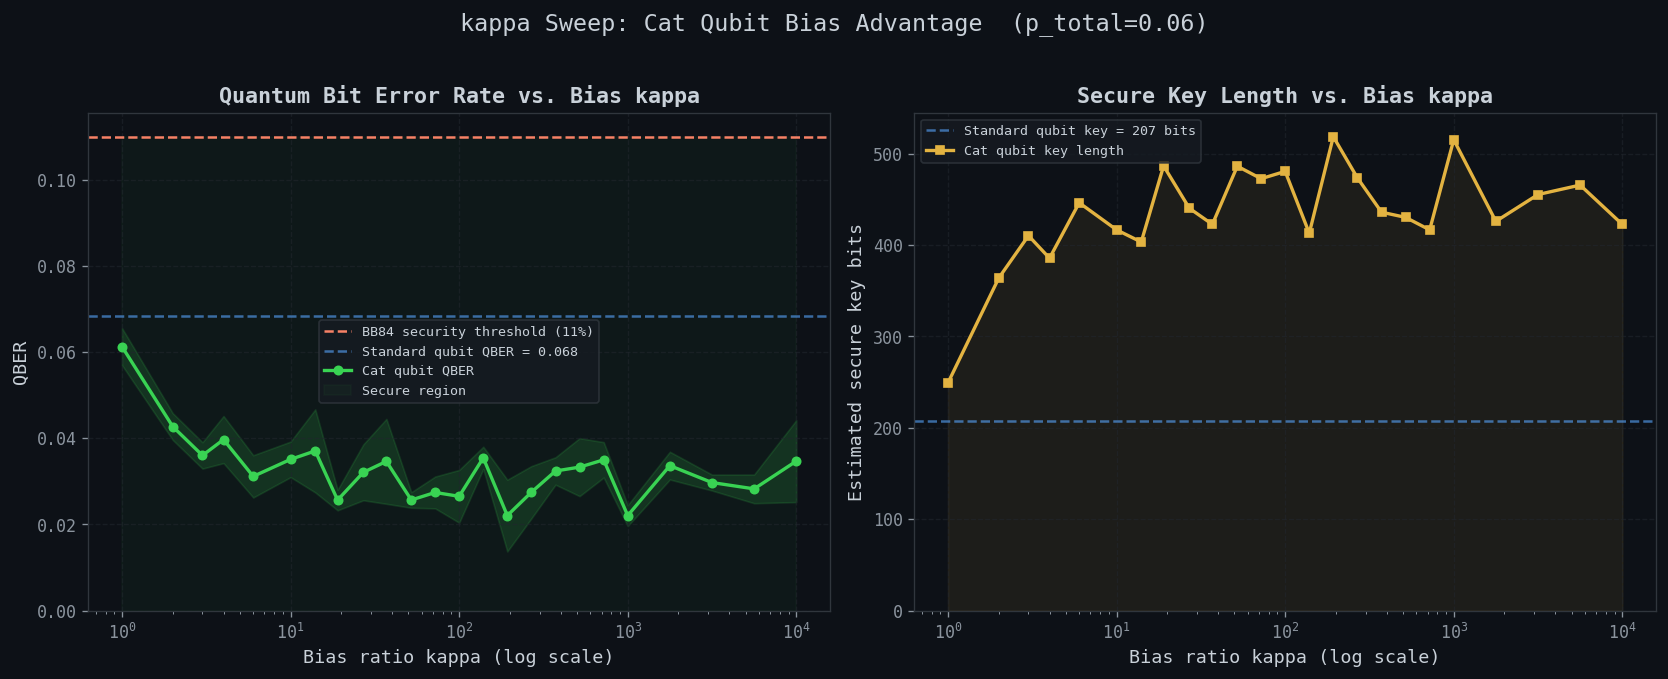

plot 1 saved


In [8]:
kappas     = [r['kappa']     for r in sweep_results]
qber_means = [r['qber_mean'] for r in sweep_results]
qber_errs  = [r['qber_err']  for r in sweep_results]
key_means  = [r['key_mean']  for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'kappa Sweep: Cat Qubit Bias Advantage  (p_total={P_TOTAL_SWEEP})',
             fontsize=14, color='#c9d1d9', y=1.02)

# QBER vs kappa
ax1.set_xscale('log')
ax1.axhline(BB84_THRESHOLD, color=ORANGE, lw=1.5, ls='--', label='BB84 security threshold (11%)')
ax1.axhline(qber_std_mean, color=BLUE, lw=1.5, ls='--', alpha=0.6,
            label=f'Standard qubit QBER = {qber_std_mean:.3f}')
ax1.fill_between(kappas,
                 np.array(qber_means) - np.array(qber_errs),
                 np.array(qber_means) + np.array(qber_errs),
                 color=TEAL, alpha=0.15)
ax1.plot(kappas, qber_means, 'o-', color=TEAL, lw=2, ms=5, label='Cat qubit QBER')
ax1.fill_between([min(kappas), max(kappas)], 0, BB84_THRESHOLD,
                 color=TEAL, alpha=0.04, label='Secure region')
ax1.set_xlabel('Bias ratio kappa (log scale)')
ax1.set_ylabel('QBER')
ax1.set_title('Quantum Bit Error Rate vs. Bias kappa')
ax1.legend(fontsize=8)
ax1.grid(True)
ax1.set_ylim(bottom=0)

# secure key length vs kappa
ax2.set_xscale('log')
ax2.axhline(key_std_mean, color=BLUE, lw=1.5, ls='--', alpha=0.6,
            label=f'Standard qubit key = {int(key_std_mean)} bits')
ax2.plot(kappas, key_means, 's-', color=YELLOW, lw=2, ms=5, label='Cat qubit key length')
ax2.fill_between(kappas, 0, key_means, color=YELLOW, alpha=0.08)
ax2.set_xlabel('Bias ratio kappa (log scale)')
ax2.set_ylabel('Estimated secure key bits')
ax2.set_title('Secure Key Length vs. Bias kappa')
ax2.legend(fontsize=8)
ax2.grid(True)
ax2.set_ylim(bottom=0)

fig.tight_layout()
plt.savefig('plot1_kappa_sweep.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('plot 1 saved')

## Plot 2 — Noise Level Sweep: QBER vs p_total

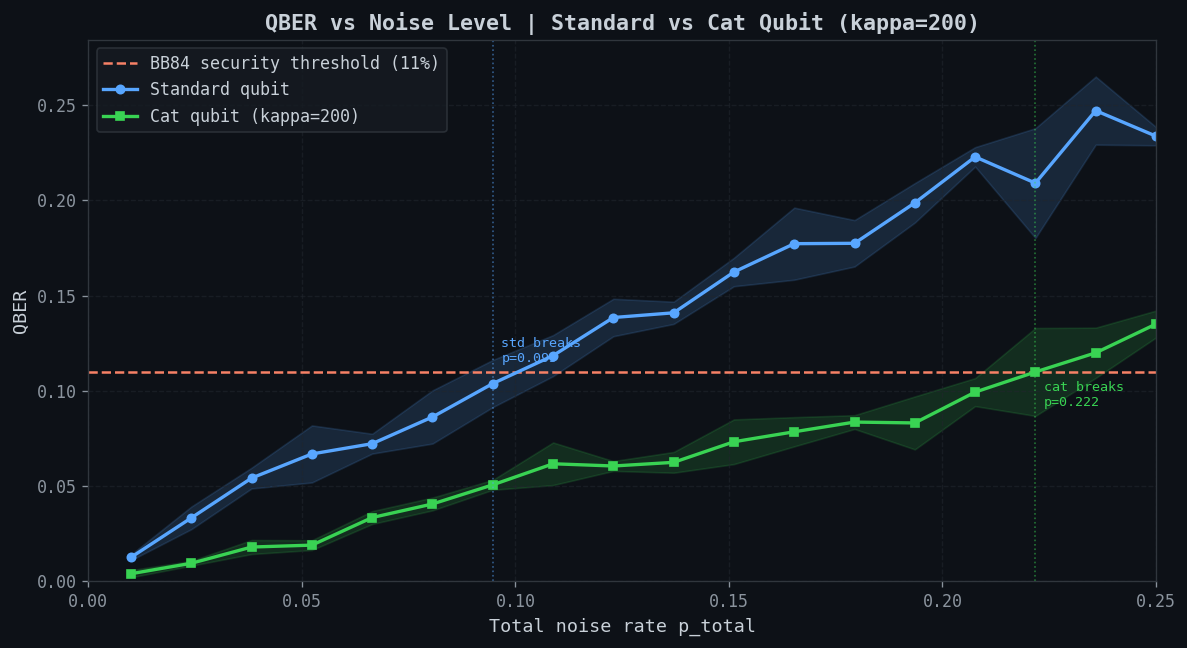

plot 2 saved


In [9]:
p_vals     = [r['p']    for r in p_sweep_std]
qber_std_p = [r['qber'] for r in p_sweep_std]
qber_std_e = [r['err']  for r in p_sweep_std]
qber_cat_p = [r['qber'] for r in p_sweep_cat]
qber_cat_e = [r['err']  for r in p_sweep_cat]

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.axhline(BB84_THRESHOLD, color=ORANGE, lw=1.5, ls='--', label='BB84 security threshold (11%)')

ax.fill_between(p_vals,
    np.array(qber_std_p) - np.array(qber_std_e),
    np.array(qber_std_p) + np.array(qber_std_e),
    color=BLUE, alpha=0.15)
ax.plot(p_vals, qber_std_p, 'o-', color=BLUE, lw=2, ms=5, label='Standard qubit')

ax.fill_between(p_vals,
    np.array(qber_cat_p) - np.array(qber_cat_e),
    np.array(qber_cat_p) + np.array(qber_cat_e),
    color=TEAL, alpha=0.15)
ax.plot(p_vals, qber_cat_p, 's-', color=TEAL, lw=2, ms=5, label=f'Cat qubit (kappa={KAPPA_FIXED})')

# mark where each model crosses the security threshold
for i in range(len(p_vals) - 1):
    if qber_std_p[i] < BB84_THRESHOLD and qber_std_p[i+1] >= BB84_THRESHOLD:
        ax.axvline(p_vals[i], color=BLUE, lw=1, ls=':', alpha=0.5)
        ax.text(p_vals[i]+0.002, BB84_THRESHOLD+0.005,
                f'std breaks\np={p_vals[i]:.3f}', color=BLUE, fontsize=8)
    if qber_cat_p[i] < BB84_THRESHOLD and qber_cat_p[i+1] >= BB84_THRESHOLD:
        ax.axvline(p_vals[i], color=TEAL, lw=1, ls=':', alpha=0.5)
        ax.text(p_vals[i]+0.002, BB84_THRESHOLD-0.018,
                f'cat breaks\np={p_vals[i]:.3f}', color=TEAL, fontsize=8)

ax.set_xlabel('Total noise rate p_total')
ax.set_ylabel('QBER')
ax.set_title(f'QBER vs Noise Level | Standard vs Cat Qubit (kappa={KAPPA_FIXED})')
ax.legend()
ax.grid(True)
ax.set_xlim(0, max(p_vals))
ax.set_ylim(0, max(max(qber_std_p), max(qber_cat_p)) * 1.15)

fig.tight_layout()
plt.savefig('plot2_noise_sweep.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('plot 2 saved')

## Plot 3 — Secure Key Rate Heatmap (Analytic)

Compute the secure key rate analytically over a 2D grid of (p_total, kappa). This gives the full operating region picture without needing to simulate every point.

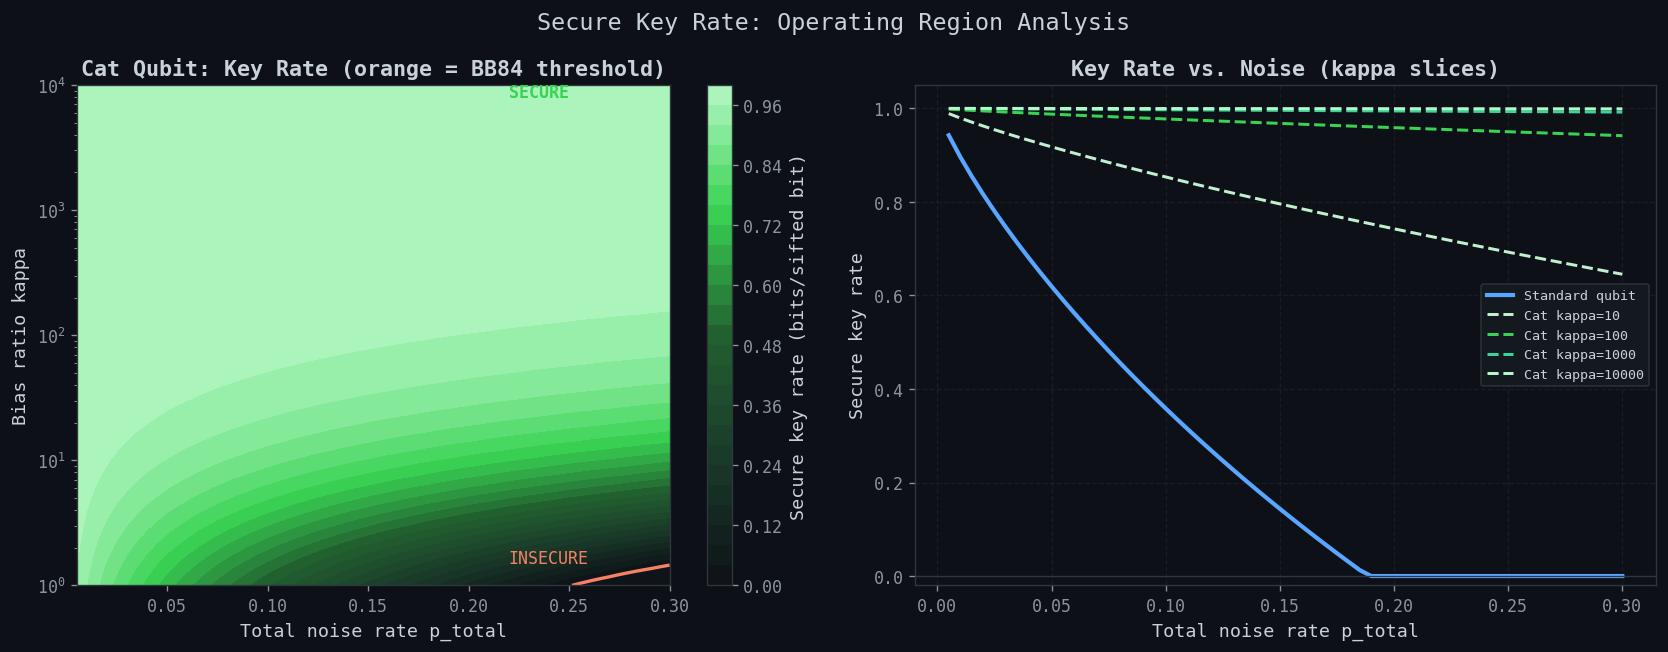

plot 3 saved


In [10]:
def h2(p):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def qber_cat_analytic(p_total, kappa):
    """Approximate QBER for cat qubit proxy.
    Z-basis QBER driven by bit-flips, X-basis QBER driven by phase-flips.
    Overall QBER is the average.
    """
    p_x   = p_total / (2 * (kappa + 1))
    p_z   = p_total * kappa / (kappa + 1)
    p_meas = (p_total / 2) / (kappa + 1)
    qber_z = np.clip(p_x + p_meas, 0, 0.5)
    qber_x = np.clip(p_z / (kappa * 2 + 2) + p_meas, 0, 0.5)
    return (qber_z + qber_x) / 2

def qber_std_analytic(p_total):
    return np.clip(p_total / 3 + (p_total / 2) / 2, 0, 0.5)

P_GRID = np.linspace(0.005, 0.30, 60)
K_GRID = np.logspace(0, 4, 60)
PP, KK = np.meshgrid(P_GRID, K_GRID)

QBER_CAT     = qber_cat_analytic(PP, KK)
KEY_RATE_CAT = np.maximum(0, 1 - 2 * h2(QBER_CAT))
KEY_RATE_STD = np.maximum(0, 1 - 2 * h2(qber_std_analytic(P_GRID)))

cmap = LinearSegmentedColormap.from_list(
    'catqubit',
    ['#0d1117', '#1a3a2a', '#21602f', '#39d353', '#b5f7c5'],
    N=256
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Secure Key Rate: Operating Region Analysis', fontsize=14, color='#c9d1d9')

# heatmap
im = ax1.contourf(PP, KK, KEY_RATE_CAT, levels=30, cmap=cmap)
ax1.contour(PP, KK, QBER_CAT, levels=[BB84_THRESHOLD], colors=[ORANGE], linewidths=2)
ax1.set_yscale('log')
ax1.set_xlabel('Total noise rate p_total')
ax1.set_ylabel('Bias ratio kappa')
ax1.set_title('Cat Qubit: Key Rate (orange = BB84 threshold)')
plt.colorbar(im, ax=ax1, label='Secure key rate (bits/sifted bit)')
ax1.text(0.22, 8000, 'SECURE',   color=TEAL,   fontsize=10, fontweight='bold')
ax1.text(0.22, 1.5,  'INSECURE', color=ORANGE, fontsize=10)

# kappa slices
ax2.plot(P_GRID, KEY_RATE_STD, color=BLUE, lw=2.5, label='Standard qubit')
for kv, col in [(10, '#c0f0d0'), (100, TEAL), (1000, '#39d3a0'), (10000, '#b5f7c5')]:
    qber_k = qber_cat_analytic(P_GRID, kv)
    key_k  = np.maximum(0, 1 - 2 * h2(qber_k))
    ax2.plot(P_GRID, key_k, lw=1.8, ls='--', color=col, label=f'Cat kappa={kv}')

ax2.axhline(0, color='#30363d', lw=0.8)
ax2.set_xlabel('Total noise rate p_total')
ax2.set_ylabel('Secure key rate')
ax2.set_title('Key Rate vs. Noise (kappa slices)')
ax2.legend(fontsize=8)
ax2.grid(True)
ax2.set_ylim(-0.02, 1.05)

fig.tight_layout()
plt.savefig('plot3_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('plot 3 saved')

## Plot 4 — Basis-Level Error Breakdown

Split the sifted key by measurement basis (Z vs X) to show where errors are coming from in each model.

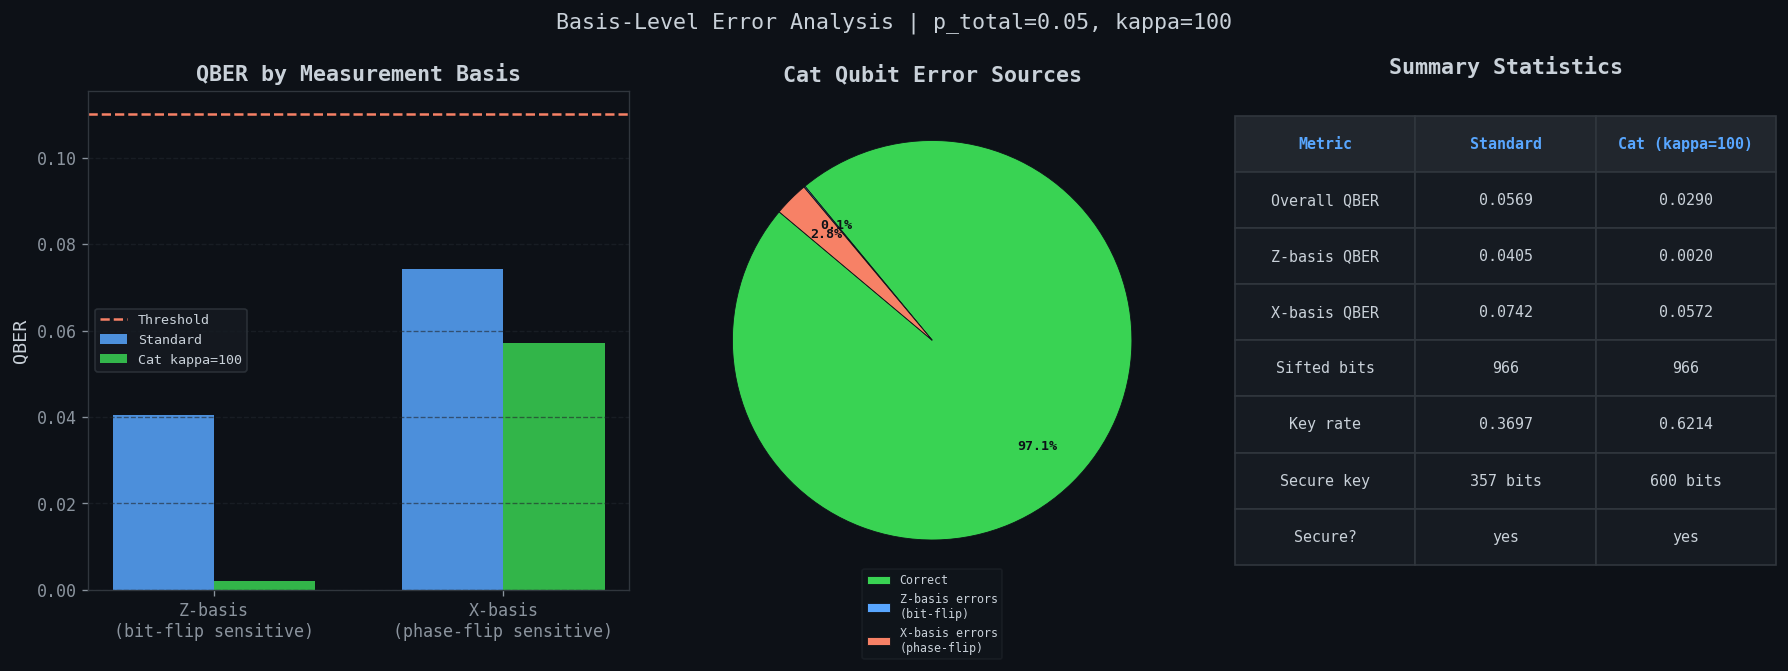

plot 4 saved


In [13]:
def basis_breakdown(res, label):
    """Compute QBER separately for Z-basis and X-basis sifted bits."""
    mask    = res['sifted_mask']
    alice_b = res['alice_bases'][mask]
    alice_k = res['alice_bits'][mask]
    bob_k   = res['bob_results'][mask]

    z_mask = alice_b == 0
    x_mask = alice_b == 1

    def qber_sub(m):
        if m.sum() == 0:
            return 0.0
        return np.sum(alice_k[m] != bob_k[m]) / m.sum()

    return {
        'label':  label,
        'qber_z': qber_sub(z_mask),
        'qber_x': qber_sub(x_mask),
        'n_z':    z_mask.sum(),
        'n_x':    x_mask.sum(),
    }

bd_std = basis_breakdown(res_std, 'Standard qubit')
bd_cat = basis_breakdown(res_cat, f'Cat qubit (kappa={KAPPA})')

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(f'Basis-Level Error Analysis | p_total={P_TOTAL}, kappa={KAPPA}',
             fontsize=13, color='#c9d1d9')

# QBER by basis bar chart
ax = axes[0]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [bd_std['qber_z'], bd_std['qber_x']], w,
       color=BLUE, alpha=0.85, label='Standard')
ax.bar(x + w/2, [bd_cat['qber_z'], bd_cat['qber_x']], w,
       color=TEAL, alpha=0.85, label=f'Cat kappa={KAPPA}')
ax.axhline(BB84_THRESHOLD, color=ORANGE, lw=1.5, ls='--', label='Threshold')
ax.set_xticks(x)
ax.set_xticklabels(['Z-basis\n(bit-flip sensitive)', 'X-basis\n(phase-flip sensitive)'])
ax.set_ylabel('QBER')
ax.set_title('QBER by Measurement Basis')
ax.legend(fontsize=8)
ax.grid(True, axis='y')

# cat qubit error source pie chart
ax = axes[1]
z_err   = bd_cat['qber_z'] * bd_cat['n_z']
x_err   = bd_cat['qber_x'] * bd_cat['n_x']
correct = (bd_cat['n_z'] + bd_cat['n_x']) - z_err - x_err

sizes  = [correct, z_err, x_err]
labels = ['Correct', 'Z-basis errors\n(bit-flip)', 'X-basis errors\n(phase-flip)']
colors = [TEAL, BLUE, ORANGE]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,          # turn off inline labels, use legend instead
    colors=colors,
    autopct='%1.1f%%',
    pctdistance=0.75,     # move percentages inside the wedges
    startangle=140,       # rotate so small slices don't overlap at right
    textprops={'fontsize': 8, 'color': '#c9d1d9'},
    wedgeprops={'linewidth': 0.5, 'edgecolor': '#0d1117'}
)

for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')
    at.set_fontsize(8)

# use legend instead of inline labels to avoid overlap
ax.legend(wedges, labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.15),
          fontsize=7,
          framealpha=0.3)

ax.set_title('Cat Qubit Error Sources')

# summary table
ax = axes[2]
ax.axis('off')
table_data = [
    ['Metric', 'Standard', f'Cat (kappa={KAPPA})'],
    ['Overall QBER',  f"{res_std['qber']:.4f}",          f"{res_cat['qber']:.4f}"],
    ['Z-basis QBER',  f"{bd_std['qber_z']:.4f}",         f"{bd_cat['qber_z']:.4f}"],
    ['X-basis QBER',  f"{bd_std['qber_x']:.4f}",         f"{bd_cat['qber_x']:.4f}"],
    ['Sifted bits',   str(res_std['n_sifted']),           str(res_cat['n_sifted'])],
    ['Key rate',      f"{res_std['key_rate']:.4f}",       f"{res_cat['key_rate']:.4f}"],
    ['Secure key',    f"{res_std['secure_key_len']} bits", f"{res_cat['secure_key_len']} bits"],
    ['Secure?',
     'yes' if res_std['qber'] < BB84_THRESHOLD else 'no',
     'yes' if res_cat['qber'] < BB84_THRESHOLD else 'no'],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc='center', loc='center', bbox=[0.0, 0.05, 1.0, 0.9])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#161b22')
    cell.set_edgecolor('#30363d')
    cell.set_text_props(color='#c9d1d9')
    if row == 0:
        cell.set_facecolor('#21262d')
        cell.set_text_props(color='#58a6ff', fontweight='bold')
ax.set_title('Summary Statistics', pad=10)

fig.tight_layout()
plt.savefig('plot4_basis_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('plot 4 saved')

## Final Summary

In [14]:
print('--- SUMMARY: BB84 QKD Performance Analysis ---')
print(f'N={N_QUBITS}, p_total={P_TOTAL}, kappa={KAPPA}\n')

print('Standard qubit:')
print(f'  QBER      = {res_std["qber"]:.4f}  ({res_std["qber"]*100:.2f}%)')
print(f'  Key rate  = {res_std["key_rate"]:.4f} bits/sifted bit')
print(f'  Secure key = {res_std["secure_key_len"]} bits')
print(f'  Secure?   = {"yes" if res_std["qber"] < BB84_THRESHOLD else "no"}')
print()

print(f'Cat qubit (kappa={KAPPA}):')
print(f'  QBER      = {res_cat["qber"]:.4f}  ({res_cat["qber"]*100:.2f}%)')
print(f'  Key rate  = {res_cat["key_rate"]:.4f} bits/sifted bit')
print(f'  Secure key = {res_cat["secure_key_len"]} bits')
print(f'  Secure?   = {"yes" if res_cat["qber"] < BB84_THRESHOLD else "no"}')
print()

qber_reduction = res_std['qber'] / max(res_cat['qber'], 1e-9)
key_gain = res_cat['secure_key_len'] - res_std['secure_key_len']
print(f'QBER reduction: {qber_reduction:.1f}x')
print(f'Key length gain: {key_gain:+d} bits')

print('\nkappa sweep (every 4th entry):')
print(f'  {"kappa":>8} | {"QBER":>8} | {"key bits":>10} | {"secure":>8}')
print(f'  {"-"*44}')
for r in sweep_results[::4]:
    status = 'yes' if r['qber_mean'] < BB84_THRESHOLD else 'no'
    print(f'  {r["kappa"]:>8} | {r["qber_mean"]:>8.4f} | {int(r["key_mean"]):>10} | {status:>8}')

--- SUMMARY: BB84 QKD Performance Analysis ---
N=2000, p_total=0.05, kappa=100

Standard qubit:
  QBER      = 0.0569  (5.69%)
  Key rate  = 0.3697 bits/sifted bit
  Secure key = 357 bits
  Secure?   = yes

Cat qubit (kappa=100):
  QBER      = 0.0290  (2.90%)
  Key rate  = 0.6214 bits/sifted bit
  Secure key = 600 bits
  Secure?   = yes

QBER reduction: 2.0x
Key length gain: +243 bits

kappa sweep (every 4th entry):
     kappa |     QBER |   key bits |   secure
  --------------------------------------------
         1 |   0.0612 |        249 |      yes
         6 |   0.0311 |        446 |      yes
        27 |   0.0321 |        440 |      yes
       100 |   0.0265 |        480 |      yes
       373 |   0.0324 |        436 |      yes
      1778 |   0.0336 |        426 |      yes
